In [1]:
import numpy as np
import pyEXP
import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.pyplot import cm
import cmasher as cmr
import pandas as pd
from astropy.table import Table, vstack
import scipy

from functools import partial
from matplotlib import animation
from matplotlib.animation import FuncAnimation
%matplotlib inline

import sys
import importlib
sys.path.append('../../code/')
import helper

In [2]:
directory = '../../data/mssa_channels_B2/'

fname_m2_int_time = directory+'m2_int_time_bins_j30_t16.dat'

coefs_m2_int_time0 = pyEXP.coefs.Coefs.factory(fname_m2_int_time)

coefs_m2_int_time = coefs_m2_int_time0.deepcopy()

fname = fname_m2_int_time

---- Coefs::factory: error opening as HDF5, trying EXP native and ascii table
---- Coefs::factory: read ascii and created TableData


In [3]:
# A list with three keys.  Keys are integer arrays (or lists).  
# The first column of the data table has the key [0], etc.
#keylst = [[i] for i in range(len(coefs.getAllCoefs()))]

n_channels = int(len(coefs_m2_int_time.getAllCoefs()))
times = coefs_m2_int_time.Times()

keylst_m2_int_time = [[i] for i in range(n_channels)]

config = {"snails_m2_int_time": (coefs_m2_int_time, keylst_m2_int_time, [])}

# Window size is half the time series (a good default choice if it's practical)
window = int(len(times)/2)

# Only compute the first 30 PCs
npc = 30

flags = """
verbose: true
"""

mssa = pyEXP.mssa.expMSSA(config, window, npc, flags)

---- Eigen is using 4 threads


In [10]:
fig_dir = '../../figures/B2_figures/m2_int_time_fiducial/'

In [5]:
ev = mssa.eigenvalues()

shape U = 86800 x 176
shape Y = 176 x 86800


In [6]:
coefs_m2_int_time.zerodata()
mssa.reconstruct([*range(30)])

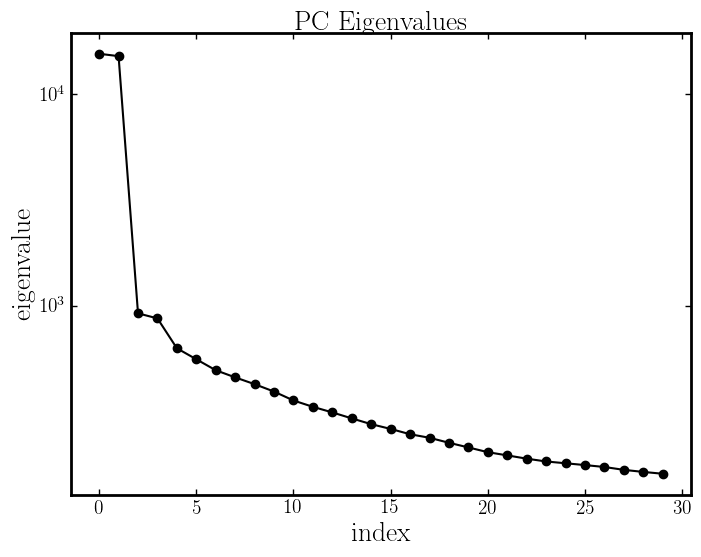

In [7]:
%matplotlib inline
fig, ax1 = plt.subplots(1, 1, figsize=(8, 6))

ax1.semilogy(ev[:30], '-o')

ax1.set_xlabel('index', fontsize=20)
ax1.set_ylabel('eigenvalue', fontsize=20)
    
ax1.set_title('PC Eigenvalues', fontsize=20)
#plt.savefig(fig_dir+'eigenvalues.pdf')
#plt.savefig(fig_dir+'eigenvalues.png')
plt.show()

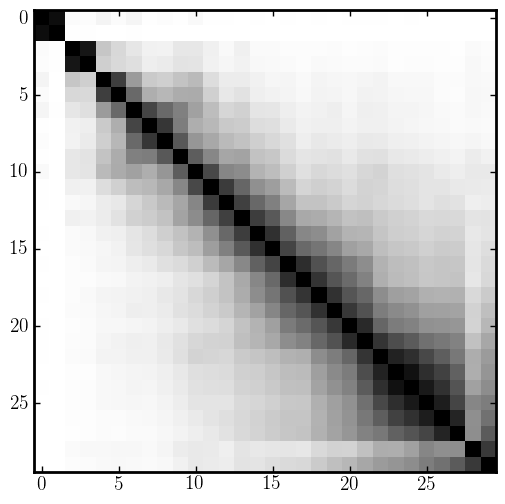

In [8]:
fig, ax = plt.subplots(1, 1, figsize=(6,6), sharey=True)

ax.imshow(mssa.wCorrAll()[:30, :30], cmap='gray_r')
#plt.savefig(fig_dir+'wCorr30.pdf')
#plt.savefig(fig_dir+'wCorr30.png') 
plt.show()

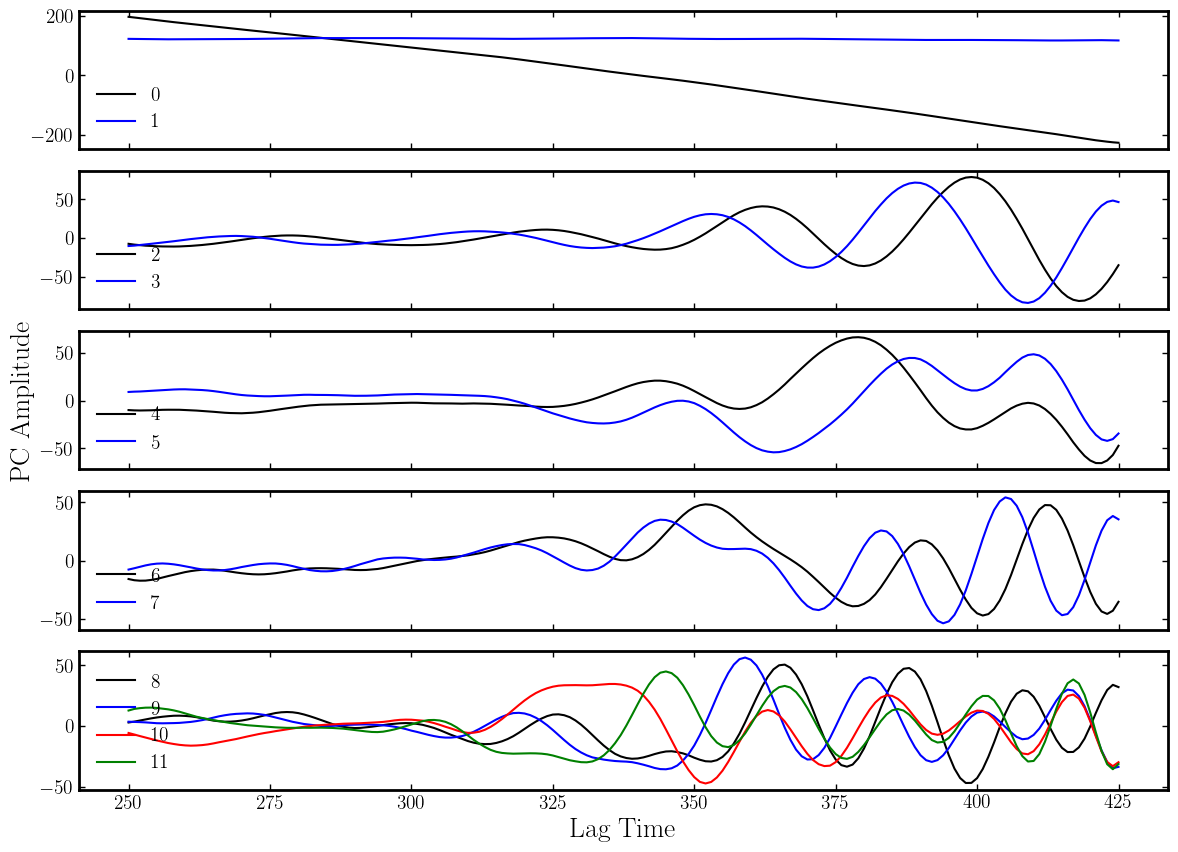

In [9]:
pc = mssa.getPC()

nt = pc.shape[0]
lag_times = times[:nt]

n_plots = 5
fig, axs = plt.subplots(n_plots, 1, figsize=(12, 1.75*n_plots), sharex=True)

for i in range(0,2):
    axs[0].plot(lag_times, pc[:,i], label=str(i)) 

# plt.suptitle('PCs, m1 amp / m2 amp', fontsize=25)

for i in range(2,4):
    axs[1].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(4,6):
    axs[2].plot(lag_times, pc[:,i], label=str(i))    
    
for i in range(6,8):
    axs[3].plot(lag_times, pc[:,i], label=str(i))
    
for i in range(8,12):
    axs[4].plot(lag_times, pc[:,i], label=str(i))  
    
# for i in range(18,22):
#     axs[5].plot(lag_times, pc[:,i], label=str(i))  

# for i in range(16,19):
#     axs[6].plot(lag_times, pc[:,i], label=str(i))  

axs[2].set_ylabel('PC Amplitude', fontsize=20)
for i in range(n_plots):
    axs[i].legend(fontsize=14, loc='lower left')
axs[-1].set_xlabel('Lag Time', fontsize=20)
        
fig.tight_layout()
#plt.savefig(fig_dir+'PCs.png')
#plt.savefig(fig_dir+'PCs.pdf') 
plt.show()

-44.75713738864708 19.30798470720137


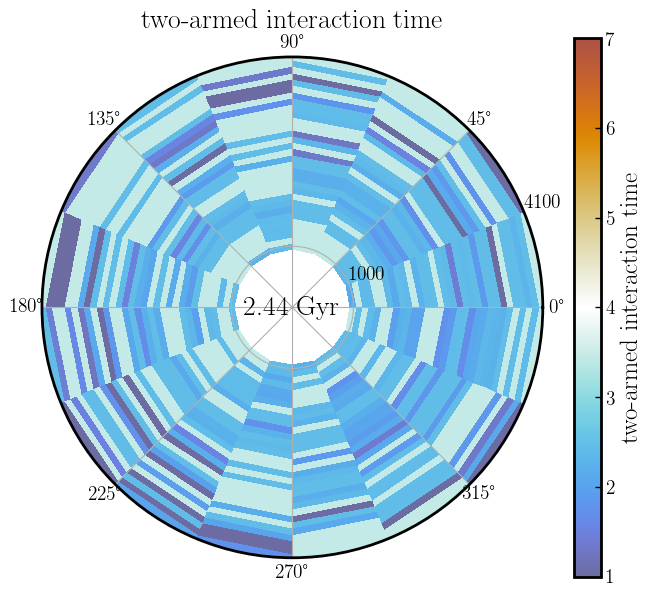

In [10]:
importlib.reload(sys.modules['helper'])
from helper import *

data_tbl = np.loadtxt(fname)
print(np.min(data_tbl[:,1:]), np.max(data_tbl[:,1:]))

f = fig_dir+'face-on_plots/data.mp4'
vmin= 1 ; vmax=7

MakeAnim = MakeAnimations(mssa=mssa, sim_name='B2', channel_name='two-armed interaction time', times=times, jphi_min=1000, jbins=31)
MakeAnim.make_data_mov(f, data_tbl, norm_function=mpl.colors.Normalize, cmap=cmr.prinsenvlag_r, vmin=1, vmax=7)

In [5]:
dat = Table.read('../../data/B2_mssa_prep_table.fits')

In [6]:
dat['rewind_time_m1'] = dat['timestep']*0.009778 - dat['time_since_int_m1']
dat['rewind_time_m2'] = dat['timestep']*0.009778 - dat['time_since_int_m2']

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/astropy/table/groups.py:396: AstropyUserWarning: Cannot aggregate column 'time_since_int_m1' with type '>f8': assignment destination is read-only
  warnings.warn(str(err), AstropyUserWarning)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/astropy/table/groups.py:396: AstropyUserWarning: Cannot aggregate column 'time_since_int_m2' with type '>f8': assignment destination is read-only
  warnings.warn(str(err), AstropyUserWarning)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/astropy/table/groups.py:291: UserWarning: Warning: converting a masked element to nan.
  vals = np.array(

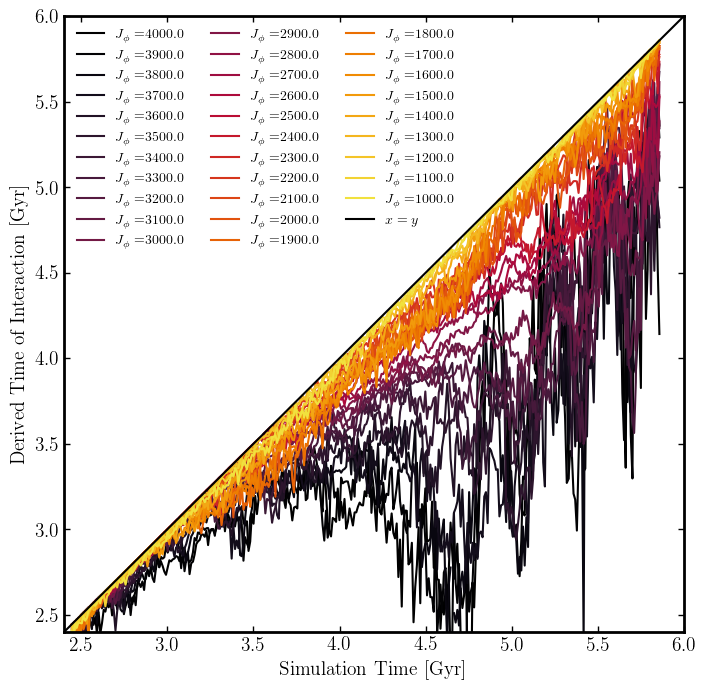

In [10]:
# to make things smoother could take median of a small range in jphi
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.set_prop_cycle(color=cmr.ember(np.linspace(0, 1, 31)))

clean_dat = dat[(dat['pitch_phase_flag_m2'] == 0) & (dat['time_since_int_m2'] > 1e-4)]
grouped_clean_dat = dat.group_by(['timestep', 'jphi_cen'])
median_grouped = grouped_clean_dat.groups.aggregate(np.median)

for jphi in np.flip(np.unique(grouped_clean_dat['jphi_cen'])):
    to_plot = median_grouped[median_grouped['jphi_cen']==jphi]
    ax.plot(to_plot['timestep'] * 0.009778, to_plot['rewind_time_m2'], label=r'$J_\phi = $'+str(jphi))
plt.plot([2.4, 6], [2.4,6], label=r'$x=y$', c='k')
plt.legend(loc='upper left', fontsize=10, ncols=3)
plt.xlim(2.4,6)
plt.ylim(2.4,6)
plt.xlabel('Simulation Time [Gyr]')
plt.ylabel('Derived Time of Interaction [Gyr]')
plt.show()

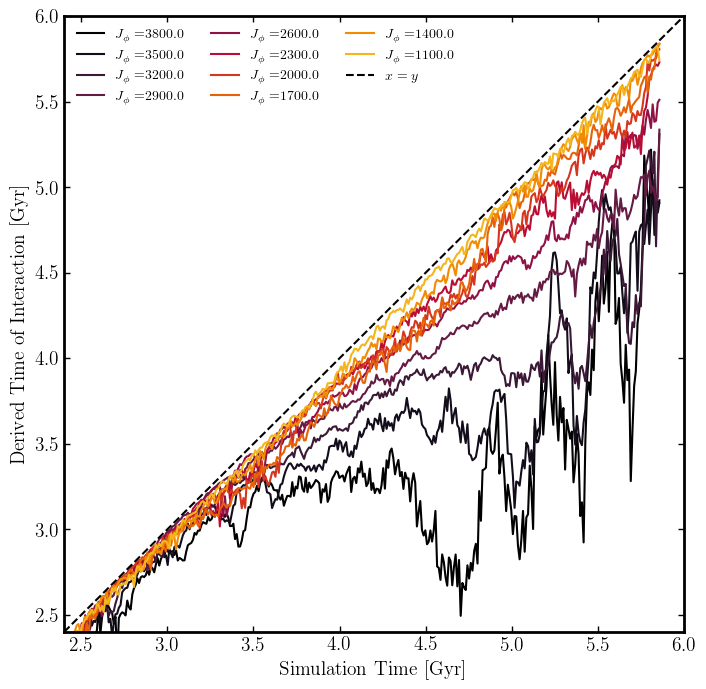

In [12]:
# to make things smoother could take median of a small range in jphi
fig, ax = plt.subplots(1,1, figsize=(8,8))
ax.set_prop_cycle(color=cmr.ember(np.linspace(0, 1, 11)))

clean_dat = dat[(dat['pitch_phase_flag_m2'] == 0) & (dat['time_since_int_m2'] > 1e-4)]
grouped_clean_dat = dat.group_by(['timestep', 'jphi_cen'])
median_grouped = grouped_clean_dat.groups.aggregate(np.median)

for jphi in np.flip(np.unique(grouped_clean_dat['jphi_cen'])[1::3]):
    clean_dat_jphi_range = clean_dat[np.abs(clean_dat['jphi_cen']-jphi) < 150]
    grouped_clean_dat_jphi_range = clean_dat_jphi_range.group_by(['timestep'])
    to_plot = grouped_clean_dat_jphi_range.groups.aggregate(np.median)
    ax.plot(to_plot['timestep'] * 0.009778, to_plot['rewind_time_m2'], label=r'$J_\phi = $'+str(jphi))
plt.plot([2.4, 6], [2.4,6], label=r'$x=y$', ls='--', c='k')
plt.legend(loc='upper left', fontsize=10, ncols=3)
ax.set_xlim(2.4,6)
ax.set_ylim(2.4,6)
ax.set_xlabel('Simulation Time [Gyr]')
ax.set_ylabel('Derived Time of Interaction [Gyr]')
plt.show() 

Updating for: (c)_0
Updating for: (s)_0
Updating for: ()_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (o)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (6)_0
Updating for: (-)_0
Updating for: (d)_0
Updating for: (S)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: (�)_0
Updating for: (?)_0
Updating for: ()_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (0)_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (m)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: (�)_0
Updating for: ()_0
Updating for: (!)_0
Updating for: (.)_0
Updating for: ()_0
Updating for: ( )_0
Updating for: ( )_0
Updating for: ( )_0


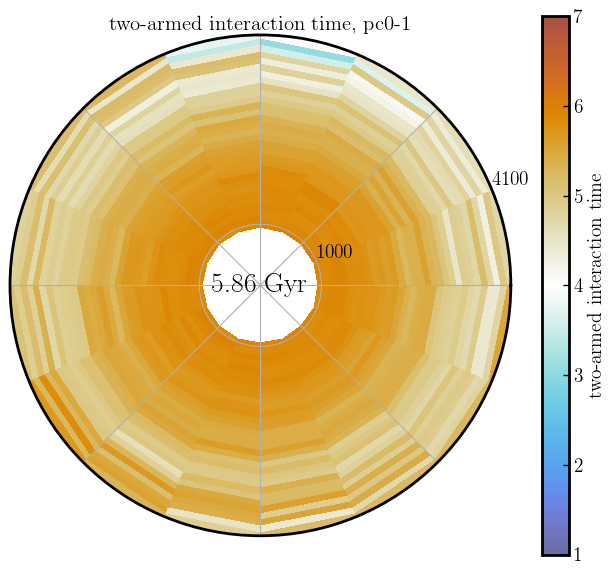

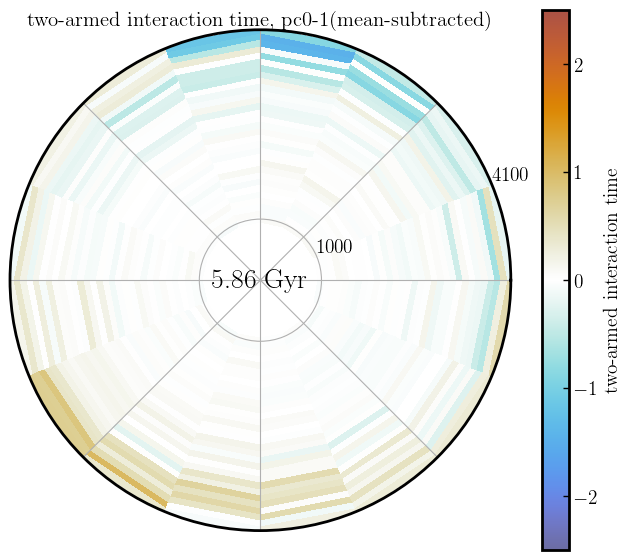

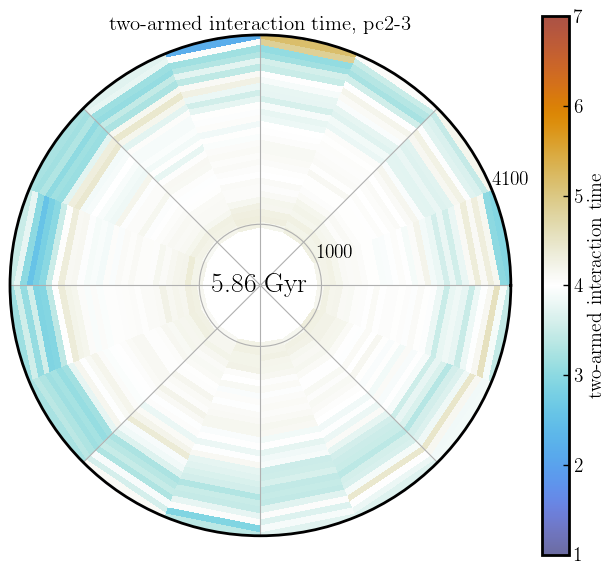

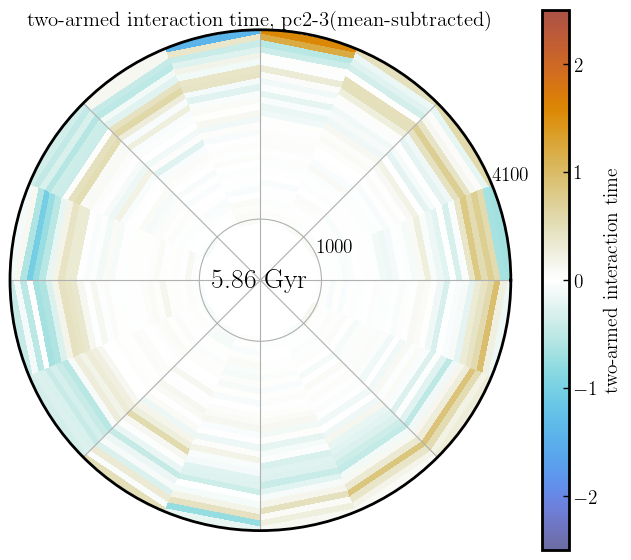

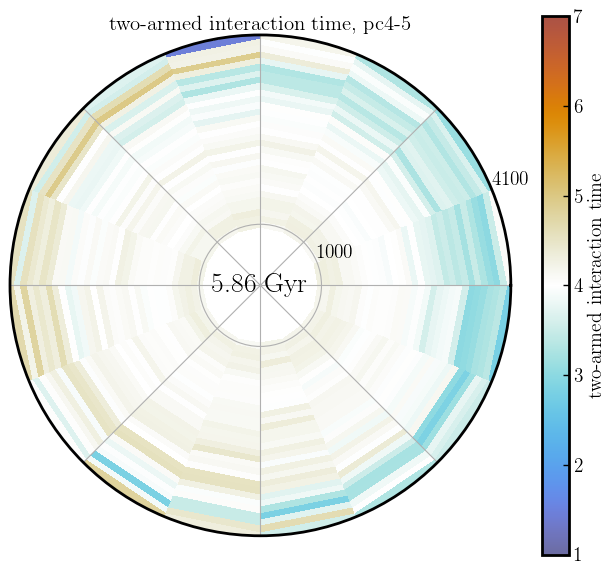

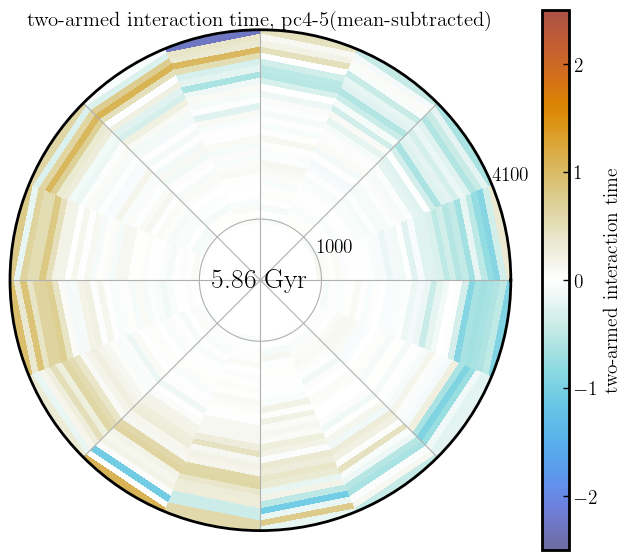

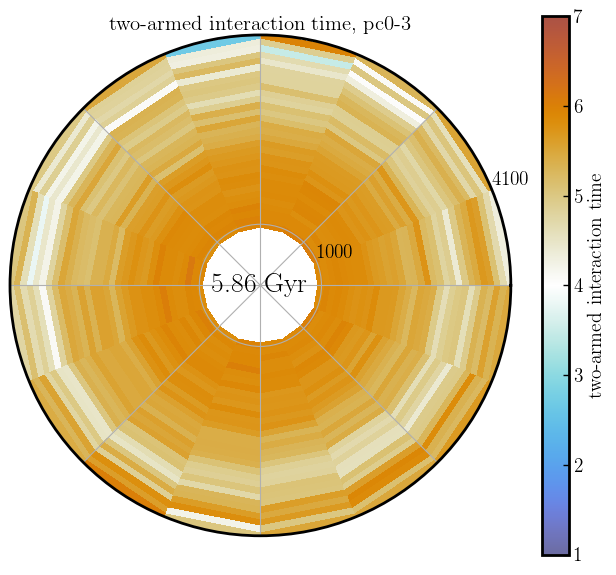

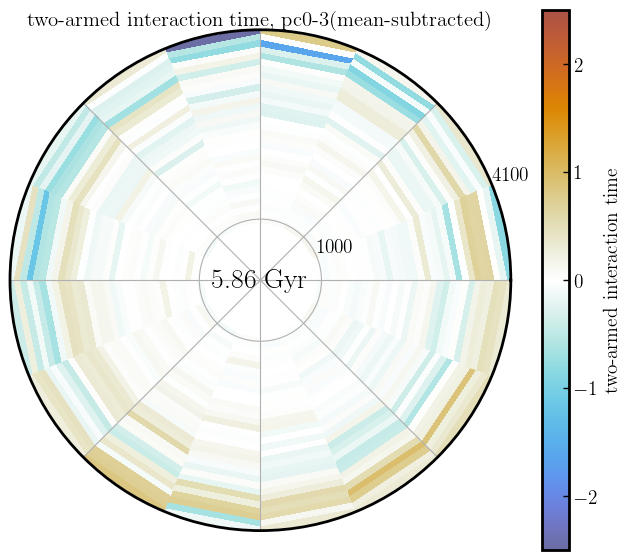

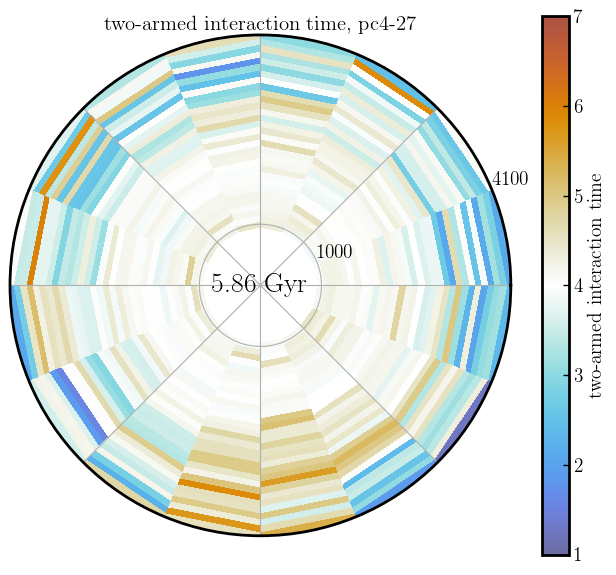

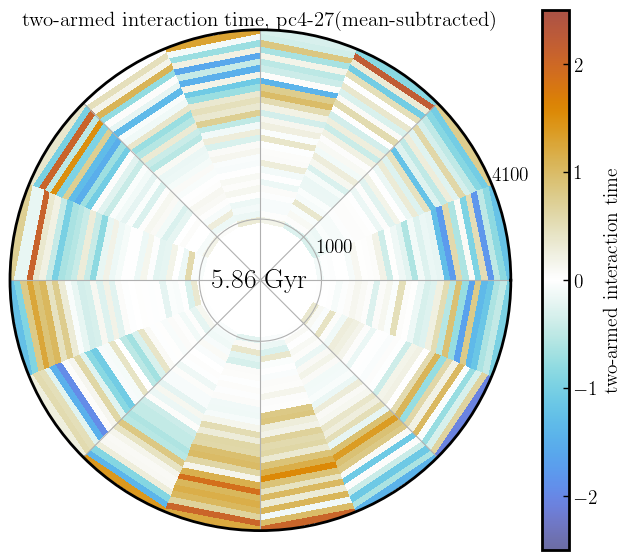

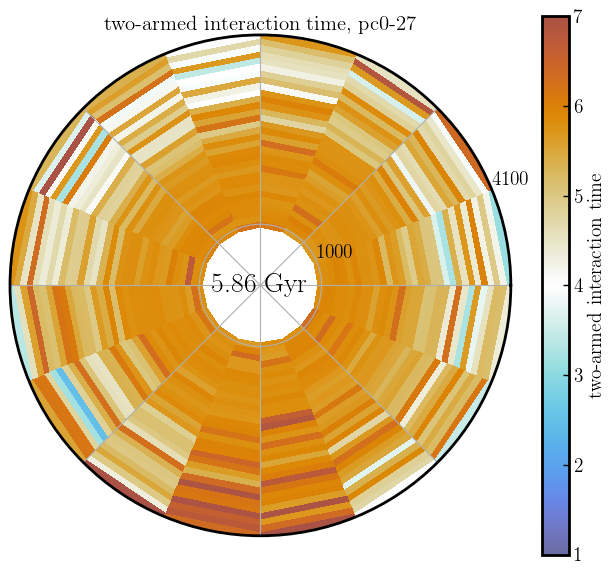

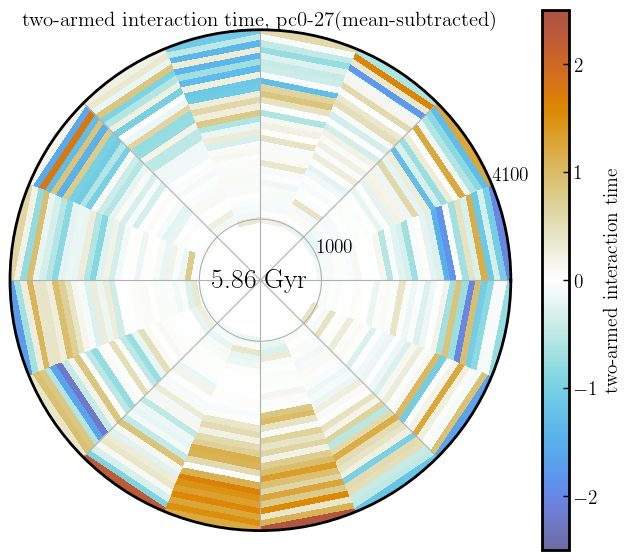

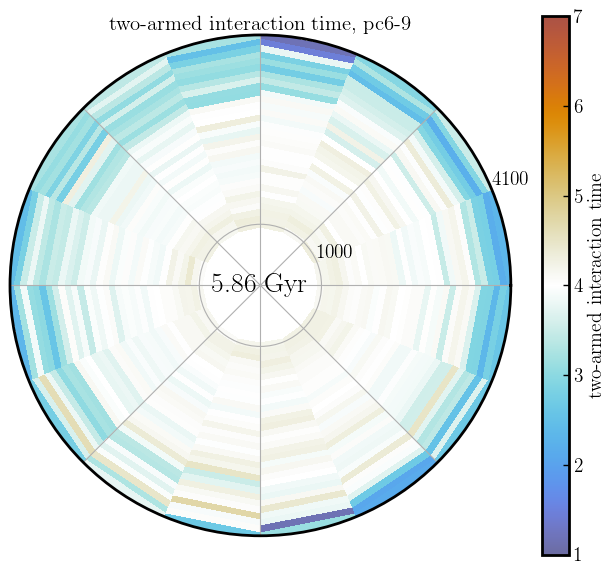

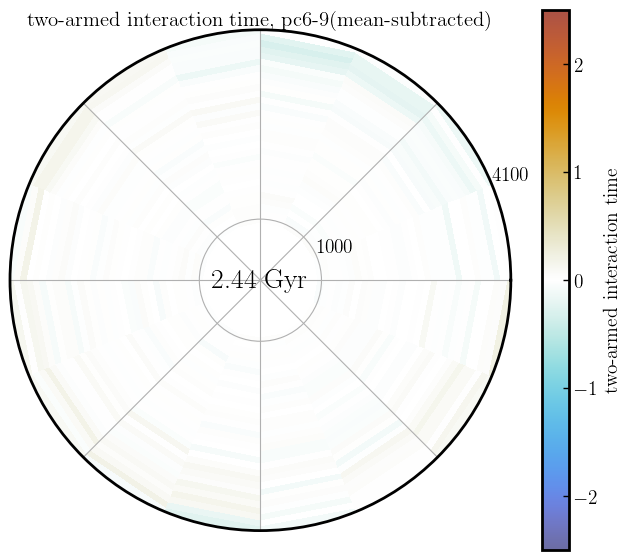

In [12]:
importlib.reload(sys.modules['helper'])
from helper import *

file_dir = fig_dir+'face-on_plots/'

list_of_pc_lists = list(([0,1], [2,3], [4,5],
                         list(range(0,4)), list(range(4,28)), 
                         list(range(0,28)), 
                         list(range(6,10))
                        ))

for pc_list in list_of_pc_lists:
    MakeAnim.reconstruct_from_pcs(pcs=pc_list)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=False, 
                                        norm_function=mpl.colors.Normalize, cmap=cmr.prinsenvlag_r, vmin=vmin, vmax=vmax)
    MakeAnim.make_pc_reconstruction_mov(file_directory=file_dir, subtract_mean=True,
                                        norm_function=mpl.colors.Normalize, cmap=cmr.prinsenvlag_r, vmin=-2.5, vmax=2.5)

## Copied from m1 int-time

In [8]:
importlib.reload(sys.modules['helper'])
from helper import *

data_tbl = np.loadtxt(fname)

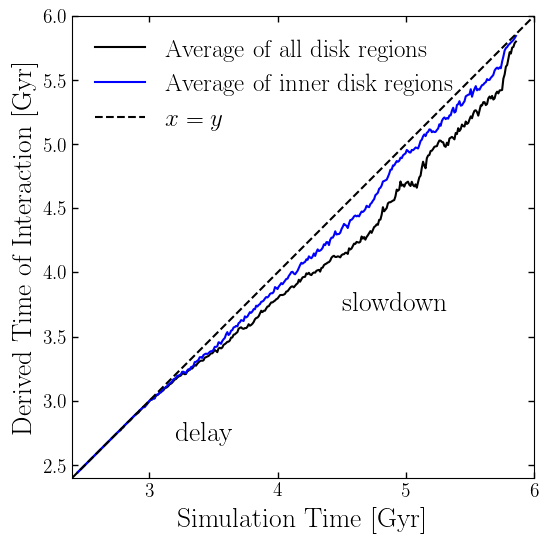

In [13]:
mpl.style.use(['default','/Users/Tavangar/.matplotlib/matplotlibrc'])

plt.figure(figsize=(6,6))
plt.plot(0.009778*data_tbl[:,0], np.median(data_tbl[:,1:], axis=1), label='Average of all disk regions', c='k')
plt.plot(0.009778*data_tbl[:,0], np.median(data_tbl[:,1:250], axis=1), label='Average of inner disk regions', c='b')
plt.plot([2.4,6], [2.4,6], label=r'$x=y$', ls='--', c='k')
plt.legend(loc='upper left', fontsize=18)
plt.xlabel('Simulation Time [Gyr]', fontsize=20)
plt.ylabel('Derived Time of Interaction [Gyr]', fontsize=20)
plt.xlim(2.4,6) ; plt.ylim(2.4,6)
ax=plt.gca()
ax.set_aspect('equal')
ax.text(3.2,2.7, 'delay', fontsize=20)
ax.text(4.5,3.7, 'slowdown', fontsize=20)
plt.savefig(fig_dir+'average_int_time.pdf')
plt.show()

In [44]:
tbl = Table.read('../../data/B2_mssa_prep_table.fits')
tbl['time_since_int_m2'][(tbl['pitch_phase_flag_m2'] > 0) | 
                        ~(tbl['time_since_int_m2'] > -np.inf) | 
                         (tbl['time_since_int_m2'] < 1e-4)] = -1

In [46]:
tbl['rewind_time_m1'] = tbl['timestep']*0.009778 - tbl['time_since_int_m1']
tbl['rewind_time_m2'] = tbl['timestep']*0.009778 - tbl['time_since_int_m2']

In [47]:
# To get colorbar
jphi_c = np.linspace(1000, 4000, 30+1)
tphi_c_ = np.linspace(0, 2*np.pi, 16+1)
rad = [0.5*(jphi_c[1] - jphi_c[0]), 0.5*(tphi_c_[1] - tphi_c_[0])]
tphi_c = tphi_c_[:-1] + rad[1]
J, T = np.meshgrid(jphi_c, tphi_c)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/numpy/_core/fromnumeric.py:870: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedColumn.
  a.partition(kth, axis=axis, kind=kind, order=order)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/astropy/table/groups.py:396: AstropyUserWarning: Cannot aggregate column 'time_since_int_m1' with type '>f8': assignment destination is read-only
  warnings.warn(str(err), AstropyUserWarning)

/Users/Tavangar/Work/EXP_Projects/snails_mssa/snails-env/lib/python3.12/site-packages/astropy/table/groups.py:291: UserWarning: Warning: converting a masked element to nan.
  vals = np.array([func(par_col[i0:i1]) for i0, i1 in zip(i0s, i1s)])



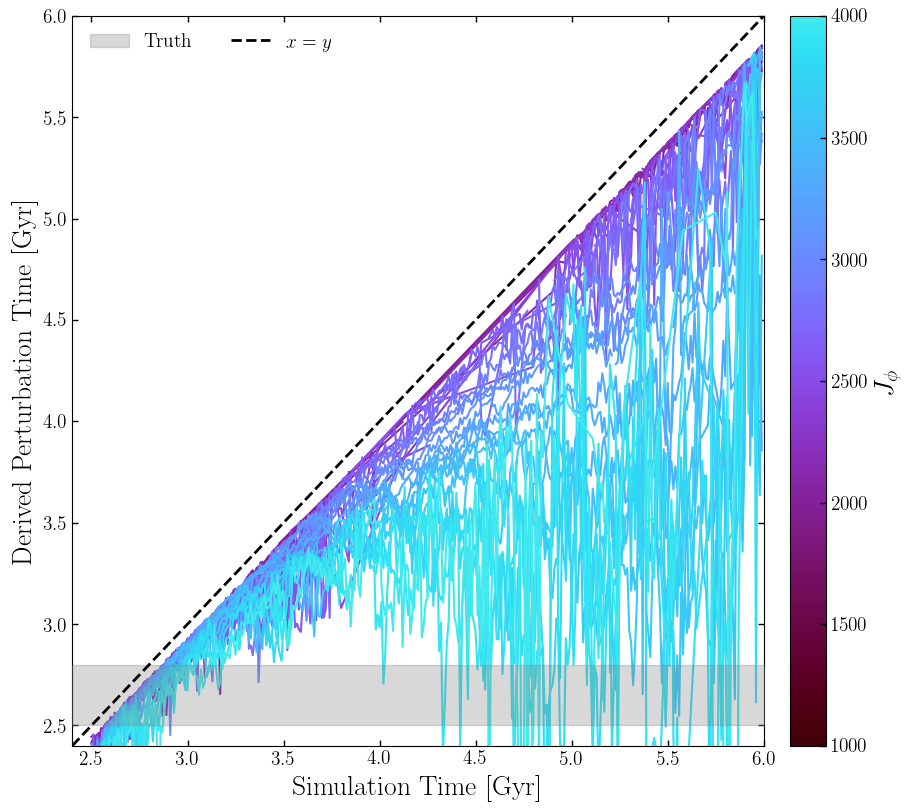

In [48]:
fig, ax = plt.subplots(1,1,figsize=(9,8), constrained_layout=True)

# Create color normalization and mappable for colorbar
norm = mpl.colors.Normalize(vmin=jphi_c.min(), vmax=jphi_c.max())
cmap = cmr.gem
sm = mpl.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])  # Required for colorbar

# Set color cycle
colors = cmap(np.linspace(0.3, 1, 31))
ax.set_prop_cycle(color=colors)

clean_dat = tbl[(tbl['time_since_int_m2'] != -1) & (tbl['m2_amp'] > tbl['m1_amp'])]
grouped_clean_dat = clean_dat.group_by(['timestep', 'jphi_cen'])
median_grouped = grouped_clean_dat.groups.aggregate(np.median)

for i, jphi in enumerate(np.unique(grouped_clean_dat['jphi_cen'])):
    to_plot = median_grouped[median_grouped['jphi_cen']==jphi]
    ax.plot(to_plot['timestep'] * 0.01, to_plot['rewind_time_m2'])
# Plot actual pertrubation time and x=y
ax.fill_between([2.4,6], 2.5, 2.8, color='gray', alpha=0.3, label='Truth', zorder=30)
plt.plot([2.4, 6], [2.4,6], label=r'$x=y$', c='k', ls='--', lw=2, zorder=30)

ax.legend(loc='upper left', fontsize=14, ncols=3)
ax.set_xlim(2.4,6) ; ax.set_ylim(2.4,6)
ax.set_xlabel('Simulation Time [Gyr]', fontsize=20)
ax.set_ylabel('Derived Perturbation Time [Gyr]', fontsize=20)
# Add colorbar
cbar = fig.colorbar(sm, ax=ax, pad=0.02)
cbar.set_label(r'$J_\phi$', fontsize=20)
# plt.savefig('nbody_winding.pdf')
plt.show()

In [43]:
tbl['timestep', 'time_since_int_m2', 'pitch_phase_flag_m2'][tbl['timestep']==350]

timestep,time_since_int_m2,pitch_phase_flag_m2
float64,float64,float64
350.0,1.1504219347321024e-17,0.0
350.0,0.24441970267869334,0.0
350.0,0.16809695573148753,0.0
350.0,0.06835620784758067,0.0
350.0,0.15126228785187817,0.0
350.0,0.22733917271116988,0.0
350.0,0.30225817740903965,0.0
350.0,0.04337728550981743,0.0
350.0,0.0455030872790958,0.0


In [39]:
pd.set_option('display.max_rows', None)
print(tbl[(tbl['m2_amp'] > tbl['m1_amp'])&(tbl['timestep']==350) & (tbl['time_since_int_m2'] != -1)].to_pandas())

     timestep  jphi_cen  tphi_cen         m0_amp       m1_amp        m2_amp  \
0       350.0    1200.0  3.730641  150979.464525  1434.798790   1500.058116   
1       350.0    1300.0  5.694137  139905.554182  1470.739172   1682.095371   
2       350.0    1300.0  6.086836  140333.015646  1498.826679   1735.113655   
3       350.0    1400.0  4.516039  127165.525088  1479.667368   1759.842674   
4       350.0    1400.0  4.908739  127403.273884  1563.414102   2352.394484   
5       350.0    1500.0  0.589049  116712.870385  1639.459920   1916.718625   
6       350.0    1500.0  4.516039  115035.807869  1310.430185   1865.491955   
7       350.0    1500.0  4.908739  113941.641881  1490.666477   2291.851091   
8       350.0    1600.0  0.589049  104695.119847  1589.310279   2115.676809   
9       350.0    1600.0  0.981748  103139.221185  1553.820232   1702.037381   
10      350.0    1600.0  2.552544  104045.625710  1114.094704   1361.344077   
11      350.0    1600.0  4.516039  104743.805666  12